# Proyecto Final — Módulo 2 (Bootcamp Data & IA)

> Flujo de datos **end-to-end**: de un CSV de Kaggle a una app de Streamlit, pasando por una base de datos en la nube.

## Objetivo

Partir de un dataset público de Kaggle, modelarlo en una base de datos relacional en la nube (TiDB), conectaros desde Python, construir un dataset analítico, hacer un EDA y exponer los resultados en una app de Streamlit.

---

### Presentación (5-10 min)

### Guión

1. **Contexto** (30s)
2. **Flujo técnico** (2 min)
3. **Hallazgos** (3-5 min)
4. **Demo Streamlit** (1-2 min)
5. **Conclusión + dificultades** (1 min)


## Esquema del flujo

```
  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
  │ CSV Kaggle   │───▶│  TiDB Cloud  │───▶│   Python     │
  │ (descarga)   │    │  (CREATE +   │    │ (mysql.      │
  │              │    │   INSERT)    │    │  connector)  │
  └──────────────┘    └──────────────┘    └──────┬───────┘
                                                  │
                                                  ▼
                                          ┌──────────────┐
                                          │  Dataset     │
                                          │  analítico   │
                                          │  (JOIN SQL)  │
                                          └──────┬───────┘
                                                  │
                                                  ▼
                                          ┌──────────────┐
                                          │  Limpieza    │
                                          │  + EDA       │
                                          └──────┬───────┘
                                                  │
                                                  ▼
                                          ┌──────────────┐
                                          │  Streamlit   │
                                          │  (dashboard) │
                                          └──────────────┘
```


---

## Fase 1 — Elección del dataset (15-30 min)

### Opción B — Spotify Dataset 1921-2020 (recomendado si os va la música)

- **Enlace:** https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks
- **Qué hay:** ~600k tracks con features de audio (energy, danceability, valence...) y catálogo de artistas.
- **Usar 2 CSV:** `tracks.csv` y `artists.csv`.
- **Relaciones:** `artists` 1—N `tracks` (a través del campo artists/id_artists).
- **Buenas preguntas:** ¿cómo ha evolucionado la energía/duración de las canciones por década? ¿qué géneros dominan en cada época? ¿hay correlación entre popularidad y features?
- **Nota:** 600k tracks es mucho — **muestread a 50-100k filas** antes de subir.


---

## Fase 2 — Crear cuenta en TiDB Cloud (10 min)
Se usará TiDB Cloud Starter (antes "Serverless"), la BBDD MySQL-compatible **gratuita y sin tarjeta**

---

## Fase 3 — Modelar y crear las tablas en SQL (30-45 min)


### 1. Apertura CSV en Pandas

In [2]:
import pandas as pd

artists = pd.read_csv("data/artists.csv")
tracks = pd.read_csv("data/tracks.csv")

print("ARTISTS")
print(artists.info())
print(artists.isnull().sum())
print(artists.head())


ARTISTS
<class 'pandas.DataFrame'>
RangeIndex: 1162095 entries, 0 to 1162094
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   id          1162095 non-null  str    
 1   followers   1162084 non-null  float64
 2   genres      1162095 non-null  str    
 3   name        1162092 non-null  str    
 4   popularity  1162095 non-null  int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 93.2 MB
None
id             0
followers     11
genres         0
name           3
popularity     0
dtype: int64
                       id  followers genres  \
0  0DheY5irMjBUeLybbCUEZ2        0.0     []   
1  0DlhY15l3wsrnlfGio2bjU        5.0     []   
2  0DmRESX2JknGPQyO15yxg7        0.0     []   
3  0DmhnbHjm1qw6NCYPeZNgJ        0.0     []   
4  0Dn11fWM7vHQ3rinvWEl4E        2.0     []   

                                             name  popularity  
0  Armid & Amir Zare Pashai feat. Sara Rouzbehani           0  
1                

In [29]:
import pandas as pd

tracks = pd.read_csv("data/tracks.csv")

print("-------------------------------")
print("TRACKS")
print(tracks.info())
print(tracks.isnull().sum())
print(tracks.head())

-------------------------------
TRACKS
<class 'pandas.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  str    
 1   name              586601 non-null  str    
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  str    
 6   id_artists        586672 non-null  str    
 7   release_date      586672 non-null  str    
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float

In [30]:
import pandas as pd

df_tracks = pd.read_csv("data/tracks.csv")

nulos = df_tracks.isnull().sum()
porcentaje = (nulos / len(df_tracks)) * 100

resultado = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje": porcentaje
})

print(resultado)

                  Nulos  Porcentaje
id                    0    0.000000
name                 71    0.012102
popularity            0    0.000000
duration_ms           0    0.000000
explicit              0    0.000000
artists               0    0.000000
id_artists            0    0.000000
release_date          0    0.000000
danceability          0    0.000000
energy                0    0.000000
key                   0    0.000000
loudness              0    0.000000
mode                  0    0.000000
speechiness           0    0.000000
acousticness          0    0.000000
instrumentalness      0    0.000000
liveness              0    0.000000
valence               0    0.000000
tempo                 0    0.000000
time_signature        0    0.000000


### 2. Columnas a Conservar

In [31]:
#### Para artists
artists = artists[[
    "id",
    "name",
    "followers",
    "popularity"
]]

#### Para tracks
tracks = tracks[[
    "id",
    "name",
    "popularity",
    "duration_ms",
    "explicit",
    "id_artists",
    "release_date",
    "danceability",
    "energy",
    "tempo"
]]

### 3. CREACIÓN DE TABLAS (SQL)

```sql 

-- Tabla padre artists (no tiene FK)
USE proyecto_final;
CREATE TABLE artists (
    id VARCHAR(22) PRIMARY KEY,
    name VARCHAR(255),
    followers BIGINT,
    popularity TINYINT
);

USE proyecto_final;
CREATE TABLE tracks (
    id VARCHAR(22) PRIMARY KEY,
    name VARCHAR(600),
    popularity TINYINT,
    duration_ms INT,
    explicit BOOLEAN,
    id_artists VARCHAR(22),
    release_date VARCHAR(10),
    danceability DECIMAL(5,3),
    energy DECIMAL(5,3),
    tempo DECIMAL(6,3),

    FOREIGN KEY (artist_id) REFERENCES artists(id)
);


---

## Fase 4 — Cargar los CSV en TiDB desde Python (30-45 min)

### Helper de carga

### 0. Mostrar CSV original artists.csv y tracks.csv

In [32]:
import pandas as pd
from pathlib import Path

# Mostrar todas las filas y columnas
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)

# Determinar ruta del CSV
csv_path = Path("data/artists.csv")
if not csv_path.exists():
	csv_files = list(Path.cwd().glob("*.csv"))
	if len(csv_files) == 1:
		csv_path = csv_files[0]
		print(f"Archivo 'artists.csv' no encontrado. Usando '{csv_path.name}' encontrado en el directorio actual.")
	else:
		raise FileNotFoundError(
			f"No se encontró 'artists.csv'. Coloca el archivo en {Path.cwd()} o cambia la ruta en el código."
		)

# Leer CSV
df = pd.read_csv(csv_path, sep=",",encoding="utf-8")

# Imprimir completo
print(df)

                             id  followers            genres  \
0        0DheY5irMjBUeLybbCUEZ2        0.0                []   
1        0DlhY15l3wsrnlfGio2bjU        5.0                []   
2        0DmRESX2JknGPQyO15yxg7        0.0                []   
3        0DmhnbHjm1qw6NCYPeZNgJ        0.0                []   
4        0Dn11fWM7vHQ3rinvWEl4E        2.0                []   
...                         ...        ...               ...   
1162090  3cOzi726Iav1toV2LRVEjp     4831.0  ['black comedy']   
1162091  6LogY6VMM3jgAE6fPzXeMl       46.0                []   
1162092  19boQkDEIay9GaVAWkUhTa      257.0                []   
1162093  5nvjpU3Y7L6Hpe54QuvDjy     2357.0  ['black comedy']   
1162094  2bP2cNhNBdKXHC6AnqgyVp       40.0    ['new comedy']   

                                                   name  popularity  
0        Armid & Amir Zare Pashai feat. Sara Rouzbehani           0  
1                                           ปูนา ภาวิณี           0  
2                    

### 1. Limpieza de CSV artists.csv y tracks.csv antes de la carga en TIDB

In [33]:
import pandas as pd
import ast
import numpy as np

# =========================
# Limpieza de artists.csv
# =========================

df_artists = pd.read_csv("data/artists.csv")

df_artists = df_artists[[
    "id",
    "name",
    "followers",
    "popularity"
]]

df_artists["name"] = df_artists["name"].fillna("Sin nombre")
df_artists["followers"] = df_artists["followers"].fillna(0)

df_artists = df_artists.drop_duplicates(subset=["id"])

df_artists.to_csv("data/artists_limpio.csv", index=False)

print("artists_limpio.csv generado\n")
print(df_artists.isnull().sum())


# =========================
# Limpieza de tracks.csv
# =========================

df_tracks = pd.read_csv("data/tracks.csv")

df_tracks["name"] = df_tracks["name"].fillna("Sin nombre")

def extraer_artist_id(valor):
    try:
        lista = ast.literal_eval(valor)
        return lista[0] if isinstance(lista, list) and len(lista) > 0 else None
    except:
        return None

df_tracks["id_artists"] = df_tracks["id_artists"].apply(extraer_artist_id)

df_tracks = df_tracks[[
    "id",
    "name",
    "popularity",
    "duration_ms",
    "explicit",
    "id_artists",
    "release_date",
    "danceability",
    "energy",
    "tempo"
]]

df_tracks["explicit"] = df_tracks["explicit"].astype(int)

df_tracks = df_tracks.dropna(subset=["id_artists"])
df_tracks = df_tracks.drop_duplicates(subset=["id"])

ids_artistas_validos = set(df_artists["id"])
df_tracks = df_tracks[df_tracks["id_artists"].isin(ids_artistas_validos)]

df_tracks.to_csv("data/tracks_limpio.csv", index=False)

print("tracks_limpio.csv generado")
print(df_tracks.isnull().sum())
print("Filas artists:", len(df_artists))
print("Filas tracks:", len(df_tracks))

artists_limpio.csv generado

id            0
name          0
followers     0
popularity    0
dtype: int64
tracks_limpio.csv generado
id              0
name            0
popularity      0
duration_ms     0
explicit        0
id_artists      0
release_date    0
danceability    0
energy          0
tempo           0
dtype: int64
Filas artists: 1162095
Filas tracks: 574812


### 2. Carga de los CSV en TiDB desde Python (30-45 min)

### 2.1. Carga de CSV limpio artists.csv (Padre) a TiDB

In [34]:
import pandas as pd
import mysql.connector
from credenciales import mysql_config


def cargar_csv_en_tabla(df, tabla, conn, batch=1000):
    """Inserta un DataFrame en una tabla de TiDB en lotes de `batch` filas."""
    cursor = conn.cursor()
    cols = ", ".join(df.columns)
    placeholders = ", ".join(["%s"] * len(df.columns))
    sql = f"INSERT INTO {tabla} ({cols}) VALUES ({placeholders})"

    filas = [tuple(None if pd.isna(v) else v for v in row)
             for row in df.itertuples(index=False, name=None)]

    for i in range(0, len(filas), batch):
        cursor.executemany(sql, filas[i:i+batch])
        conn.commit()
        print(f"  insertadas {min(i+batch, len(filas))}/{len(filas)}")
    cursor.close()

# Adaptación de columnas al csv artists.csv:
df_artists = pd.read_csv("data/artists_limpio.csv")

df_artists = df_artists[[
    "id",
    "name",
    "followers",
    "popularity"
]]

conn = mysql.connector.connect(**mysql_config)
cargar_csv_en_tabla(df_artists, "artists", conn, batch=500)
conn.close()

  insertadas 500/1162095
  insertadas 1000/1162095
  insertadas 1500/1162095
  insertadas 2000/1162095
  insertadas 2500/1162095
  insertadas 3000/1162095
  insertadas 3500/1162095
  insertadas 4000/1162095
  insertadas 4500/1162095
  insertadas 5000/1162095
  insertadas 5500/1162095
  insertadas 6000/1162095
  insertadas 6500/1162095
  insertadas 7000/1162095
  insertadas 7500/1162095
  insertadas 8000/1162095
  insertadas 8500/1162095
  insertadas 9000/1162095
  insertadas 9500/1162095
  insertadas 10000/1162095
  insertadas 10500/1162095
  insertadas 11000/1162095
  insertadas 11500/1162095
  insertadas 12000/1162095
  insertadas 12500/1162095
  insertadas 13000/1162095
  insertadas 13500/1162095
  insertadas 14000/1162095
  insertadas 14500/1162095
  insertadas 15000/1162095
  insertadas 15500/1162095
  insertadas 16000/1162095
  insertadas 16500/1162095
  insertadas 17000/1162095
  insertadas 17500/1162095
  insertadas 18000/1162095
  insertadas 18500/1162095
  insertadas 19000/11

### 2.2. Limpieza de Registros con error de Foreing Key

In [46]:
import pandas as pd
import mysql.connector
from credenciales import mysql_config

# Cargar tracks limpio
df_tracks = pd.read_csv("data/tracks_limpio.csv")

# Conectar a TiDB
conn = mysql.connector.connect(**mysql_config)

# Traer artists realmente cargados en TiDB
df_artists_db = pd.read_sql("SELECT id FROM artists", conn)

conn.close()

# Crear conjunto de IDs válidos
ids_validos = set(df_artists_db["id"])

# Separar registros correctos e incorrectos
df_tracks_correctos = df_tracks[df_tracks["id_artists"].isin(ids_validos)]
df_tracks_error = df_tracks[~df_tracks["id_artists"].isin(ids_validos)]

# Guardar ambos CSV
df_tracks_correctos.to_csv("data/tracks_para_cargar.csv", index=False)
df_tracks_error.to_csv("data/tracks_con_error_fk.csv", index=False)

print("Tracks correctos:", len(df_tracks_correctos))
print("Tracks con error FK:", len(df_tracks_error))

C:\Users\Randy Bonucci Martín\AppData\Local\Temp\ipykernel_32644\1900529930.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_artists_db = pd.read_sql("SELECT id FROM artists", conn)


Tracks correctos: 574812
Tracks con error FK: 0


### 2.2.1. Carga de CSV (Hijo) tracks_para_cargar.csv

In [36]:
df_tracks = pd.read_csv("data/tracks_para_cargar.csv")
conn = mysql.connector.connect(**mysql_config)
cargar_csv_en_tabla(df_tracks, "tracks", conn, batch=500)
conn.close()

  insertadas 500/574812
  insertadas 1000/574812
  insertadas 1500/574812
  insertadas 2000/574812
  insertadas 2500/574812
  insertadas 3000/574812
  insertadas 3500/574812
  insertadas 4000/574812
  insertadas 4500/574812
  insertadas 5000/574812
  insertadas 5500/574812
  insertadas 6000/574812
  insertadas 6500/574812
  insertadas 7000/574812
  insertadas 7500/574812
  insertadas 8000/574812
  insertadas 8500/574812
  insertadas 9000/574812
  insertadas 9500/574812
  insertadas 10000/574812
  insertadas 10500/574812
  insertadas 11000/574812
  insertadas 11500/574812
  insertadas 12000/574812
  insertadas 12500/574812
  insertadas 13000/574812
  insertadas 13500/574812
  insertadas 14000/574812
  insertadas 14500/574812
  insertadas 15000/574812
  insertadas 15500/574812
  insertadas 16000/574812
  insertadas 16500/574812
  insertadas 17000/574812
  insertadas 17500/574812
  insertadas 18000/574812
  insertadas 18500/574812
  insertadas 19000/574812
  insertadas 19500/574812
  inse

---

## Fase 5 — Extracción del DataSet Analítico (15-30 min)

### 5.1. Consulta (Patrón)

In [78]:
conn = mysql.connector.connect(**mysql_config)

query = """
SELECT
    t.id AS track_id,
    t.name AS track_name,
    t.popularity AS track_popularity,
    t.duration_ms,
    t.explicit,
    t.release_date,
    t.danceability,
    t.energy,
    t.tempo,
    a.id AS id_artists,
    a.name AS artist_name,
    a.followers,
    a.popularity AS artist_popularity
FROM tracks t
JOIN artists a ON t.id_artists = a.id
"""

df = pd.read_sql(query, conn)
conn.close()

df.head()

C:\Users\Randy Bonucci Martín\AppData\Local\Temp\ipykernel_32644\2665820535.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,track_id,track_name,track_popularity,duration_ms,explicit,release_date,danceability,energy,tempo,id_artists,artist_name,followers,artist_popularity
0,5KlAbz9VZVLQK4aSK1quoD,SOUL LOVE,46,269693,0,2009-10-21,0.404,0.960,163.874,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
1,5EATRvFKKtd7DjEL0UmAlV,グロリアス,43,295893,0,2009-10-21,0.444,0.955,146.794,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
2,4tCtZzE58XDHUAZjoCZiPg,"Winter,again",49,314933,0,2009-10-21,0.517,0.806,113.809,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
3,4nQwb8JdCNteesn1SRlwbX,Way of Difference,41,297773,0,2009-06-10,0.583,0.749,106.739,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
4,4aykSGQFnGbeKe5sw7pN2I,BELOVED,48,288200,0,2009-10-21,0.556,0.912,111.118,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53


---

## Fase 6 — Limpieza y preprocesamiento
### 6.1. Generación de DataSet Analítico

In [79]:
import pandas as pd
# Creación de DataSet Analítico
df.to_parquet("dataset/dataset_analitico.parquet", index=False)

# Leer  DataSet Analítico
df = pd.read_parquet("dataset/dataset_analitico.parquet")

# Guardar dataset limpio en pickle
df.to_pickle("dataset/dataset_analitico_limpio.pkl")

# Leer dataset desde pickle
df = pd.read_pickle("dataset/dataset_analitico_limpio.pkl")

display(df.head())

,track_id,track_name,track_popularity,duration_ms,explicit,release_date,danceability,energy,tempo,id_artists,artist_name,followers,artist_popularity
0,5KlAbz9VZVLQK4aSK1quoD,SOUL LOVE,46,269693,0,2009-10-21,0.404,0.960,163.874,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
1,5EATRvFKKtd7DjEL0UmAlV,グロリアス,43,295893,0,2009-10-21,0.444,0.955,146.794,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
2,4tCtZzE58XDHUAZjoCZiPg,"Winter,again",49,314933,0,2009-10-21,0.517,0.806,113.809,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
3,4nQwb8JdCNteesn1SRlwbX,Way of Difference,41,297773,0,2009-06-10,0.583,0.749,106.739,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53
4,4aykSGQFnGbeKe5sw7pN2I,BELOVED,48,288200,0,2009-10-21,0.556,0.912,111.118,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53


### 6.2. Revisar tipos de datos

In [80]:
print(df.dtypes)

track_id                 str
track_name               str
track_popularity       int64
duration_ms            int64
explicit               int64
release_date             str
danceability         float64
energy               float64
tempo                float64
id_artists               str
artist_name              str
followers              int64
artist_popularity      int64
dtype: object


### 6.3. Conversión de Tipos
### Se convirtieron las fechas a formato datetime, la variable explicit a booleana y artist_name a categórica para optimizar memoria y facilitar el análisis.

In [82]:
# Fecha
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# Booleano
df["explicit"] = df["explicit"].astype("bool")

# Categóricas
df["artist_name"] = df["artist_name"].astype("category")

print(df.dtypes)

track_id                        str
track_name                      str
track_popularity              int64
duration_ms                   int64
explicit                       bool
release_date         datetime64[us]
danceability                float64
energy                      float64
tempo                       float64
id_artists                      str
artist_name                category
followers                     int64
artist_popularity             int64
dtype: object


### 6.4. Revisar Nulos

In [81]:
print(df.isna().sum())

track_id             0
track_name           0
track_popularity     0
duration_ms          0
explicit             0
release_date         0
danceability         0
energy               0
tempo                0
id_artists           0
artist_name          0
followers            0
artist_popularity    0
dtype: int64


##### La revisión de valores nulos mostró que la mayoría de columnas no presentaban datos faltantes. Sin embargo, la columna release_date contenía 130.340 registros nulos. Esto ocurrió debido a inconsistencias en el formato de fechas del dataset original durante la conversión a tipo datetime.

##### Dado que la fecha de lanzamiento es importante para el análisis temporal del proyecto, se decidió eliminar las filas sin fecha válida usando dropna(subset=["release_date"]).

##### La columna followers solo presentó un valor nulo, considerado poco significativo respecto al tamaño total del dataset.

### 6.4.1. Tratamiento de Nulos
##### Los nulos en nombres de canciones se reemplazaron por "Sin nombre". Las filas sin fecha de lanzamiento se eliminaron porque afectan análisis temporales.

In [83]:
# Contar nombres faltantes antes de reemplazar
nombres_faltantes = df["track_name"].isna().sum()

# Reemplazar nombres faltantes
df["track_name"] = df["track_name"].fillna("Sin nombre")

print("Nombres faltantes reemplazados:", nombres_faltantes)

# Contar filas sin fecha antes de eliminar
filas_sin_fecha = df["release_date"].isna().sum()
print("Filas sin fecha antes de eliminar:", filas_sin_fecha)

# Eliminar filas sin fecha
df = df.dropna(subset=["release_date"])

print("Filas sin fecha eliminadas:", filas_sin_fecha)
print("Filas finales:", len(df))

Nombres faltantes reemplazados: 0
Filas sin fecha antes de eliminar: 137004
Filas sin fecha eliminadas: 137004
Filas finales: 437808


##### En esta fase no se detectaron nombres faltantes porque ese problema ya fue tratado previamente durante la limpieza previa a la carga en TiDB. En concreto, los nombres faltantes fueron reemplazados por "Sin nombre" antes de generar el dataset analítico.

### 6.4.2. Revisar Duplicados

In [84]:
print(df.duplicated().sum())

0


<span style="color:#00FF00;">■</span>  No se encontraron datos Duplicados

### 6.4.3. Eliminación de Duplicados

In [85]:
df = df.drop_duplicates()
print(df)

                      track_id         track_name  track_popularity  \
0       5KlAbz9VZVLQK4aSK1quoD          SOUL LOVE                46   
1       5EATRvFKKtd7DjEL0UmAlV              グロリアス                43   
2       4tCtZzE58XDHUAZjoCZiPg       Winter,again                49   
3       4nQwb8JdCNteesn1SRlwbX  Way of Difference                41   
4       4aykSGQFnGbeKe5sw7pN2I            BELOVED                48   
...                        ...                ...               ...   
574805  1igaC3NsHsK3otkV4cC6bv               Mars                 4   
574806  1OppgfDi0T99BZcnQdSvbJ     Nice Questions                 3   
574807  0K7Ds3icknRZO4EcG3zhy3          Cyclotron                 7   
574808  0BoYXFlRrUJNmSAgecCPJm      The Set Break                 4   
574809  74Uyg48KzZmJIXA302c5nA    Sunset Concerto                 3   

        duration_ms  explicit release_date  danceability  energy    tempo  \
0            269693     False   2009-10-21         0.404   0.960  163.

<span style="color:#00FF00;">■</span> No habían registros duplicados que eliminar para el análisis

### 6.4.4. Revisión de Outliers

#### Se verificaron valores atípicos en duración y popularidad para detectar errores de calidad de datos.

In [86]:
# Outliers en popularidad
outliers_popularity = df[
    (df["track_popularity"] < 0) | 
    (df["track_popularity"] > 100)
]

# Outliers en duración
outliers_duration = df[
    df["duration_ms"] < 0
]

# Resultado
print("Outliers en popularidad:", len(outliers_popularity))
print("Outliers en duración negativa:", len(outliers_duration))

if outliers_popularity.empty and outliers_duration.empty:
    print("No se encontraron outliers evidentes.")
    print("La popularidad está dentro del rango 0-100 y no hay duraciones negativas.")
else:
    print("Se encontraron posibles outliers. Revisar los DataFrames anteriores.")

Outliers en popularidad: 0
Outliers en duración negativa: 0
No se encontraron outliers evidentes.
La popularidad está dentro del rango 0-100 y no hay duraciones negativas.


### 6.4.5. Creación de columnas derivadas

In [87]:
# Año
df["release_year"] = df["release_date"].dt.year

# Mes
df["release_month"] = df["release_date"].dt.month

# Día de la semana
df["release_day_name"] = df["release_date"].dt.day_name()

# Categoría de popularidad
df["popularity_category"] = pd.cut(
    df["track_popularity"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

print("Columnas derivadas creadas:")

columnas_derivadas = [
    "release_year",
    "release_month",
    "release_day_name",
    "popularity_category"
]

for col in columnas_derivadas:
    print("-", col)

Columnas derivadas creadas:
- release_year
- release_month
- release_day_name
- popularity_category


### 6.4.6. DataSet Final Limpio

In [88]:
# Guardado local en formato Pickle
df.to_pickle("dataset/dataset_analitico_limpio.pkl")

# Comprobación de lectura
df_pickle = pd.read_pickle("dataset/dataset_analitico_limpio.pkl")

display(df_pickle.head())

,track_id,track_name,track_popularity,duration_ms,explicit,release_date,danceability,energy,tempo,id_artists,artist_name,followers,artist_popularity,release_year,release_month,release_day_name,popularity_category
0,5KlAbz9VZVLQK4aSK1quoD,SOUL LOVE,46,269693,False,2009-10-21,0.404,0.960,163.874,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium
1,5EATRvFKKtd7DjEL0UmAlV,グロリアス,43,295893,False,2009-10-21,0.444,0.955,146.794,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium
2,4tCtZzE58XDHUAZjoCZiPg,"Winter,again",49,314933,False,2009-10-21,0.517,0.806,113.809,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium
3,4nQwb8JdCNteesn1SRlwbX,Way of Difference,41,297773,False,2009-06-10,0.583,0.749,106.739,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,6,Wednesday,Medium
4,4aykSGQFnGbeKe5sw7pN2I,BELOVED,48,288200,False,2009-10-21,0.556,0.912,111.118,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium


#### Además del formato Parquet, se guardó una copia local en formato Pickle (.pkl). Este formato permite conservar el DataFrame de pandas con sus tipos de datos y transformaciones, facilitando su reutilización posterior sin repetir todo el proceso de extracción y limpieza.

### 6.4.7.Flujo de limpieza y preprocesamiento

#### 1. Revisar

Primero se explora el dataset para comprender su estructura y calidad inicial.

#### Objetivos

- Identificar las columnas disponibles.
- Revisar los tipos de datos.
- Contar registros.
- Detectar valores nulos o inconsistencias.

#### Código utilizado

```python
df.info()

df.head()

df.isna().sum()
```

####  2. Detectar problemas

Después se identifican posibles problemas que puedan afectar el análisis.

#### Problemas revisados

- Valores nulos.
- Registros duplicados.
- Tipos de datos incorrectos.
- Outliers evidentes.
- Formatos inconsistentes.

#### Código utilizado

```python
df.duplicated().sum()

df[df["duration_ms"] < 0]
```

#### Explicación

El objetivo es detectar errores o inconsistencias en los datos que puedan generar resultados incorrectos durante el análisis exploratorio.

---

### 3. Justificar decisiones

Cada transformación realizada debe estar justificada.

#### Ejemplos

- Reemplazo de nombres faltantes.
- Eliminación de filas sin fecha.
- Conservación o eliminación de outliers.

#### Ejemplo de justificación

```text
Los nombres faltantes fueron reemplazados por "Sin nombre"
para conservar registros válidos del dataset.
```

#### Explicación

No basta con limpiar los datos; también es importante explicar por qué se toman determinadas decisiones durante el preprocesamiento.

---

### 4. Transformar

En esta fase se aplican las transformaciones necesarias para preparar el dataset.

#### Transformaciones realizadas

- Conversión de tipos de datos.
- Eliminación de duplicados.
- Reemplazo de valores nulos.
- Creación de columnas derivadas.
- Filtrado de registros inválidos.

#### Código utilizado

```python
df["release_date"] = pd.to_datetime(df["release_date"])

df["track_name"] = df["track_name"].fillna("Sin nombre")
```

#### Explicación

Estas transformaciones permiten preparar el dataset para análisis exploratorio, visualización y futuras tareas analíticas.

---

### 5. Guardar dataset limpio

Finalmente se guarda una versión limpia y preparada del dataset.

#### Código utilizado

```python
df.to_parquet("dataset_analitico_limpio.parquet")

df.to_pickle("dataset_analitico_limpio.pkl")
```

#### Explicación

Se genera una versión final del dataset ya procesado para reutilizarlo posteriormente sin repetir todas las etapas de limpieza y transformación.

---

## Fase 7 — EDA (45-60 min)

El EDA es la fase donde **descubrís la historia** del dataset. No es "hacer gráficos sueltos", es **responder preguntas**.

### Estructura

1. **Descripción general** (5 min): cuántas filas, qué periodo, qué variables.
2. **Univariante** (15 min): distribución de cada variable importante (histogramas, boxplots, value_counts).
3. **Bivariante** (20 min): relación entre variables (scatter, barras por grupo, correlaciones).
4. **Hallazgos** (10 min): 3-5 conclusiones claras con un gráfico cada una.


#### 7.1. Descripción general del dataset
#### El dataset contiene información de canciones y artistas de Spotify, incluyendo popularidad, duración, métricas musicales y fechas de lanzamiento.

In [89]:
import pandas as pd

df = pd.read_pickle("dataset/dataset_analitico_limpio.pkl")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df.head())

print(df.info())

Filas: 437808
Columnas: 17


,track_id,track_name,track_popularity,duration_ms,explicit,release_date,danceability,energy,tempo,id_artists,artist_name,followers,artist_popularity,release_year,release_month,release_day_name,popularity_category
0,5KlAbz9VZVLQK4aSK1quoD,SOUL LOVE,46,269693,False,2009-10-21,0.404,0.960,163.874,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium
1,5EATRvFKKtd7DjEL0UmAlV,グロリアス,43,295893,False,2009-10-21,0.444,0.955,146.794,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium
2,4tCtZzE58XDHUAZjoCZiPg,"Winter,again",49,314933,False,2009-10-21,0.517,0.806,113.809,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium
3,4nQwb8JdCNteesn1SRlwbX,Way of Difference,41,297773,False,2009-06-10,0.583,0.749,106.739,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,6,Wednesday,Medium
4,4aykSGQFnGbeKe5sw7pN2I,BELOVED,48,288200,False,2009-10-21,0.556,0.912,111.118,00AFbqxvdDK6T1D6MQZ9c1,GLAY,299012,53,2009,10,Wednesday,Medium


<class 'pandas.DataFrame'>
Index: 437808 entries, 0 to 574809
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   track_id             437808 non-null  str           
 1   track_name           437808 non-null  str           
 2   track_popularity     437808 non-null  int64         
 3   duration_ms          437808 non-null  int64         
 4   explicit             437808 non-null  bool          
 5   release_date         437808 non-null  datetime64[us]
 6   danceability         437808 non-null  float64       
 7   energy               437808 non-null  float64       
 8   tempo                437808 non-null  float64       
 9   id_artists           437808 non-null  str           
 10  artist_name          437808 non-null  category      
 11  followers            437808 non-null  int64         
 12  artist_popularity    437808 non-null  int64         
 13  release_year         437808 no

### 7.2. Análisis univariante

#### 7.2.1. Distribución de popularidad de canciones

#### Insight

La mayoría de canciones presentan niveles medios de popularidad, mientras que pocas alcanzan valores extremadamente altos.

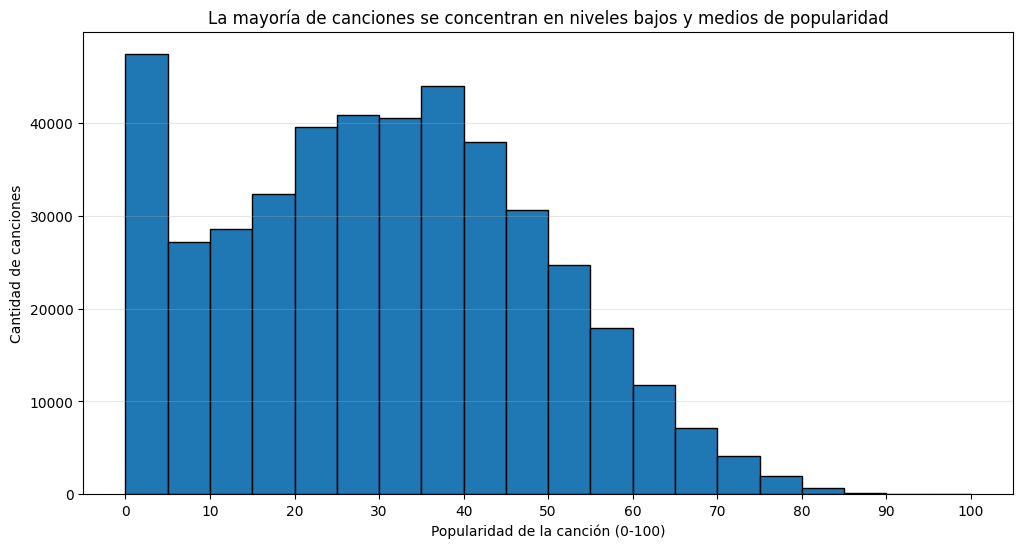

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(
    df["track_popularity"],
    bins=20,
    edgecolor="black"
)

plt.title("La mayoría de canciones se concentran en niveles bajos y medios de popularidad")
plt.xlabel("Popularidad de la canción (0-100)")
plt.ylabel("Cantidad de canciones")

plt.xticks(range(0, 101, 10))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 7.2.2. Distribución de duración

#### Insight

La mayor parte de canciones tienen duraciones relativamente similares, concentradas en pocos minutos.


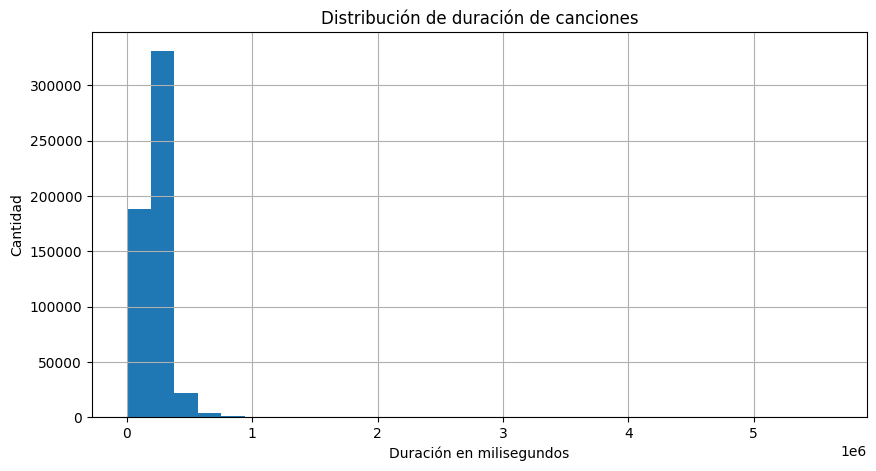

In [61]:
plt.figure(figsize=(10,5))

df["duration_ms"].hist(bins=30)

plt.title("Distribución de duración de canciones")
plt.xlabel("Duración en milisegundos")
plt.ylabel("Cantidad")

plt.show()

### 7.2.3. BoxPlot de Energía

#### Insight

La energía presenta valores altos en gran parte de las canciones, aunque existen algunos valores atípicos.

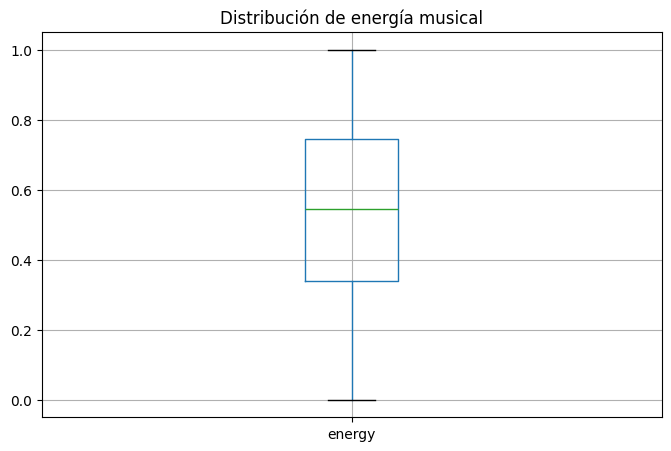

In [62]:
plt.figure(figsize=(8,5))

df.boxplot(column="energy")

plt.title("Distribución de energía musical")

plt.show()

#### 7.2.3.1. Análisis Gráfico 
#### Boxplot de la variable `energy`

El boxplot permite visualizar la distribución de la variable `energy`, que representa el nivel de intensidad o energía musical de las canciones.

La caja central representa el 50% principal de los datos:

- El límite inferior corresponde al 25% de los valores.
- La línea central representa la mediana.
- El límite superior corresponde al 75% de los valores.

Las líneas externas o “bigotes” muestran el rango de valores considerados normales dentro de la distribución.

Los puntos que aparecen fuera de los bigotes representan posibles valores atípicos (*outliers*), es decir, canciones con niveles de energía muy diferentes al comportamiento general del dataset.

La variable `energy` toma valores entre 0 y 1:

- Valores cercanos a 0 representan canciones más tranquilas.
- Valores cercanos a 1 representan canciones más intensas o enérgicas.

Este gráfico permite identificar:

- Si la mayoría de canciones tienen niveles altos o bajos de energía.
- Qué tan dispersos están los valores.
- Si existen canciones extremadamente energéticas o muy suaves respecto al resto.
- El eje vertical representa directamente los valores de energía.
- La caja central contiene el 50% principal de los datos.
- La línea dentro de la caja representa la mediana.
- Los “bigotes” muestran el rango de valores considerados normales.
- Los puntos fuera de los bigotes representan posibles valores atípicos (*outliers*).

#### 7.2.4 Análisis bivariante 
##### 7.2.4.1. Relación entre energía y popularidad
##### Insight

No se observa una correlación fuerte entre energía y popularidad, aunque canciones con energía media-alta parecen concentrar más éxitos.

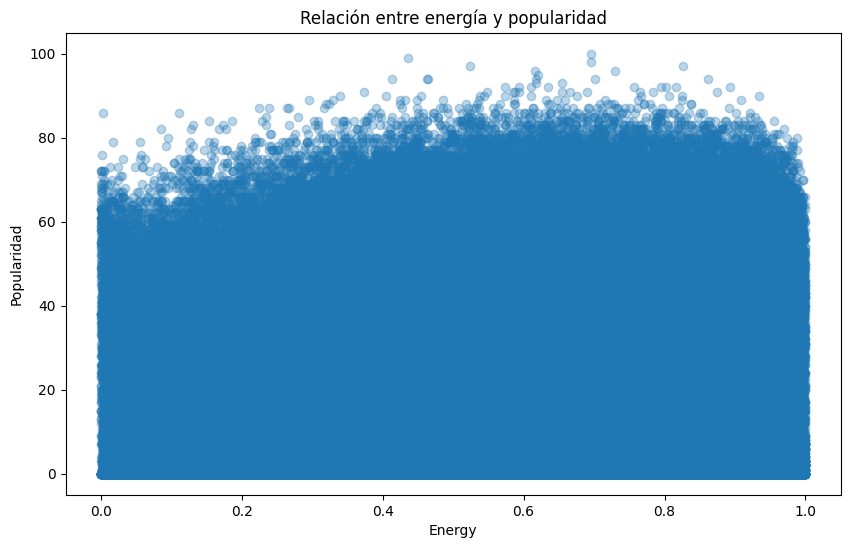

In [63]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["energy"],
    df["track_popularity"],
    alpha=0.3
)

plt.title("Relación entre energía y popularidad")
plt.xlabel("Energy")
plt.ylabel("Popularidad")

plt.show()

#### 7.2.4.2. Evolución temporal de canciones lanzadas

#### Insight

El volumen de canciones aumenta considerablemente en las últimas décadas.


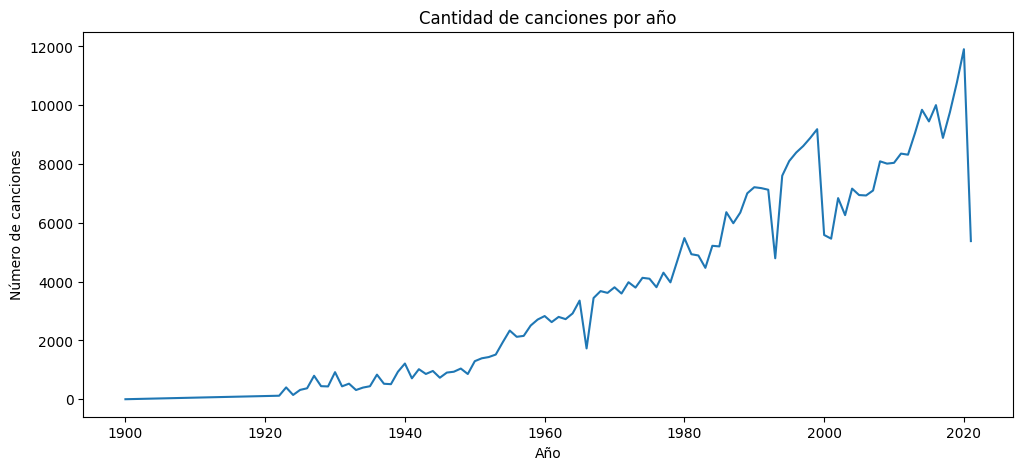

In [64]:
canciones_por_anio = df.groupby("release_year").size()

plt.figure(figsize=(12,5))

canciones_por_anio.plot()

plt.title("Cantidad de canciones por año")
plt.xlabel("Año")
plt.ylabel("Número de canciones")

plt.show()

#### 7.2.4.3. Top 10 artistas con más seguidores
#### Insight

Existe una fuerte concentración de seguidores en pocos artistas muy populares.

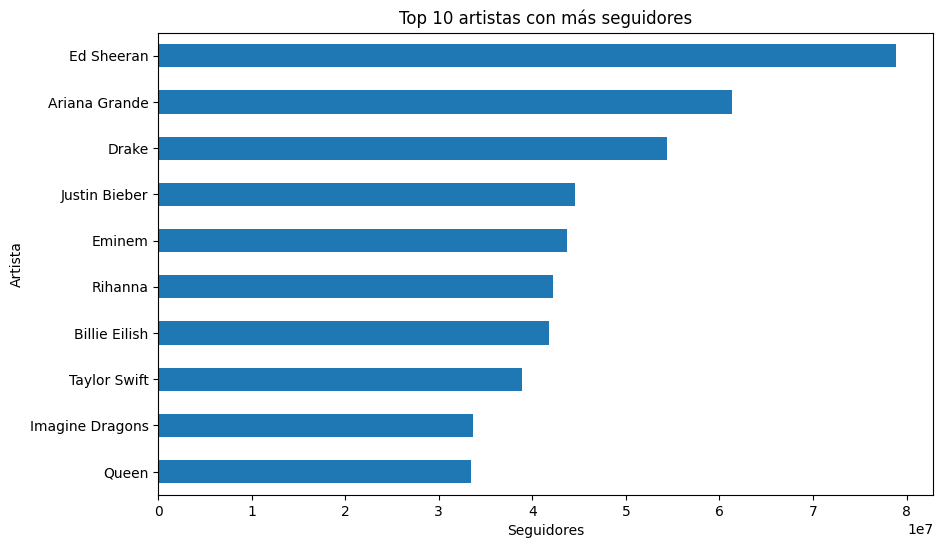

In [65]:
top_artistas = (
    df.groupby("artist_name")["followers"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_artistas.sort_values().plot.barh()

plt.title("Top 10 artistas con más seguidores")
plt.xlabel("Seguidores")
plt.ylabel("Artista")

plt.show()

### 7.2.4.4. Correlaciones

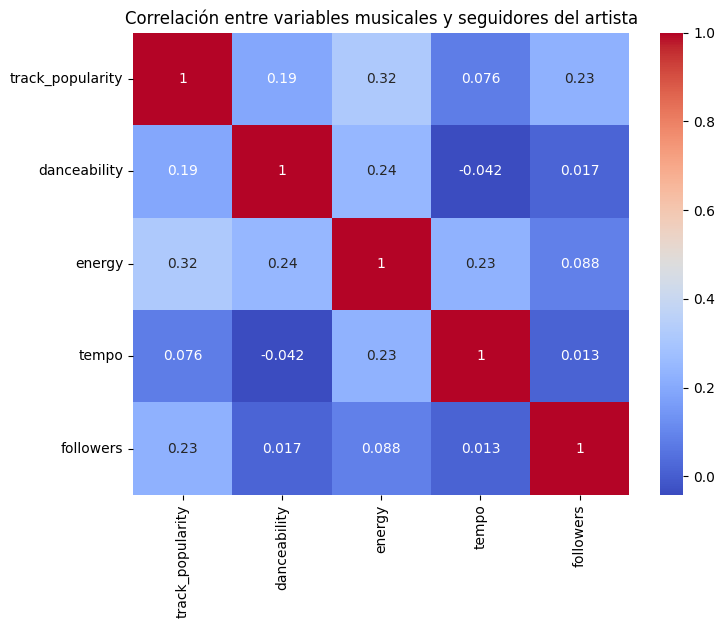

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[[
    "track_popularity",
    "danceability",
    "energy",
    "tempo",
    "followers"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlación entre variables musicales y seguidores del artista")

plt.show()

#### 7.2.4.4. Detalles del mapa de correlaciones

El heatmap de correlaciones permite visualizar la relación entre variables numéricas del dataset.

Cada celda representa el nivel de correlación entre dos variables utilizando valores entre `-1` y `1`:

- Valores cercanos a `1` indican una correlación positiva fuerte.
- Valores cercanos a `-1` indican una correlación negativa fuerte.
- Valores cercanos a `0` indican poca o ninguna relación lineal.

En este análisis se compararon variables musicales y de popularidad:

- `track_popularity`
- `danceability`
- `energy`
- `tempo`
- `followers`

El objetivo es identificar si algunas características musicales presentan relación con la popularidad de las canciones o con la cantidad de seguidores del artista.

Los colores del gráfico ayudan a interpretar rápidamente la intensidad de la correlación:

- Colores cálidos representan correlaciones positivas.
- Colores fríos representan correlaciones negativas.

Este tipo de gráfico facilita detectar patrones y posibles relaciones relevantes para el análisis exploratorio del dataset.

#### 7.2.4.5. Hallazgos finales

Hallazgos principales:

1. La mayoría de canciones presentan popularidad media.
2. El número de lanzamientos musicales crece con el tiempo.
3. Existe una fuerte concentración de seguidores en pocos artistas.
4. No se observan correlaciones muy fuertes entre variables musicales y popularidad.
5. La popularidad del artista parece influir más que las características musicales individuales.

---

## Fase 8 — Dashboard con Streamlit (60-90 min)

### Boilerplate

### Está contenido en dashboard/app.py